# HDT 4: Regresión Logística y Métricas

**Ciencia de Datos, Sección A** · Asignada: jueves 17 de septiembre · **Entrega: martes 22 de septiembre, 23:59**

**Nombre:** George Albadr

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semilla fija y split fijo): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Una empresa de internet residencial quiere saber qué clientes van a cancelar. Historial de 1,200 clientes: `mensualidad` (quetzales al mes), `meses` (antigüedad como cliente), `reclamos` (en el último año) y `cancelo` (1 = canceló el servicio). Es el mismo tipo de problema que la mora de la sesión 14, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [2]:
rng = np.random.default_rng(9)
n = 1200
mensualidad = rng.normal(350, 90, n).clip(150, 700).round(0)
meses = rng.integers(1, 61, n)
reclamos = np.minimum(rng.poisson(0.8, n), 6)

riesgo = -1.1 + 0.006 * (mensualidad - 350) - 0.06 * meses + 0.9 * reclamos
cancelo = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"mensualidad": mensualidad, "meses": meses,
                   "reclamos": reclamos, "cancelo": cancelo})
print("clientes:", len(df), "| fracción que canceló:", df["cancelo"].mean().round(3))
df.head()

clientes: 1200 | fracción que canceló: 0.169


,mensualidad,meses,reclamos,cancelo
0,278.0,48,0,0
1,372.0,46,0,0
2,201.0,7,0,0
3,409.0,24,2,0
4,453.0,48,3,0


## Parte A · El modelo (0.5 pt)

Regresión logística como en la sesión 14: una suma con pesos que la sigmoide convierte en una probabilidad entre 0 y 1.

### Ejercicio 1 (0.15): entrenar y leer los pesos

Entrenar el pipeline de clase (StandardScaler + LogisticRegression) sobre el split dado. Extraer el punto de partida `b` y los tres `pesos`, e imprimirlos con el nombre de su columna. Responder en un comentario: ¿qué columna protege más contra la cancelación?

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

columnas = ["mensualidad", "meses", "reclamos"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["cancelo"], test_size=0.3, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression())
modelo.fit(X_train, y_train)

b = modelo[1].intercept_[0]  # intercept de la regresión (modelo[1])
pesos = modelo[1].coef_[0]   # los tres coeficientes, en el orden de `columnas`

# imprimir b y cada peso con su columna
# Respuesta: La columna ue mas protege en general es meses por tener la mayor diferencia en los pesos.
print(f"b = {b:.2f}")
for i, (column, peso) in enumerate(zip(columnas, pesos)):
    print(f"{column}: {peso:.2f}")
# Verificación (descomentar):
assert round(b, 2) == -2.29
assert [round(w, 2) for w in pesos] == [0.64, -1.35, 0.62]

b = -2.29
mensualidad: 0.64
meses: -1.35
reclamos: 0.62


### Ejercicio 2 (0.20): un cliente, a mano

Cliente nuevo: paga Q380, lleva 4 meses, puso 2 reclamos. Calcular su probabilidad de cancelar sin `predict_proba`: (a) escalar cada valor con `escalador.mean_` y `escalador.scale_`, (b) armar la suma `b + w1 * x1 + w2 * x2 + w3 * x3`, (c) pasarla por la sigmoide. Luego comparar contra `modelo.predict_proba`: deben coincidir.

In [4]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

cliente = pd.DataFrame({"mensualidad": [380.0], "meses": [4], "reclamos": [2]})

# el escalador es modelo[0]; sus medias y desviaciones: .mean_ y .scale_
z = b + modelo[0].transform(cliente)[0].dot(pesos)          # ¿Qué va aquí? escalar el cliente y sumar con los pesos
p_mano = sigmoide(z)
p_sklearn = modelo.predict_proba(cliente)[0, 1]  # con modelo.predict_proba(cliente)

# Verificación (descomentar):
assert round(p_mano, 3) == round(p_sklearn, 3) == 0.721

### Ejercicio 3 (0.15): equivocarse con confianza cuesta caro

El castigo de una predicción es `-log(p asignada a lo que realmente pasó)`. (a) Calcular el castigo para un cliente que sí canceló al que el modelo le dijo 0.99, 0.9, 0.5, 0.1 y 0.01. (b) Con `log_loss`, el castigo promedio del modelo en test contra el de un modelo tibio que le dice 0.5 a todo el mundo.

In [5]:
from sklearn.metrics import log_loss

p_dijo = np.array([0.99, 0.9, 0.5, 0.1, 0.01])
castigos = -np.log(p_dijo)   # ¿Qué va aquí?

prob = modelo.predict_proba(X_test)[:, 1]       # las probabilidades del test, con modelo.predict_proba
castigo_modelo = log_loss(y_test, prob)
castigo_tibio = log_loss(y_test, np.full(len(y_test), 0.5))   # contra np.full(len(y_test), 0.5)

# Verificación (descomentar):
assert round(castigos[-1], 1) == 4.6
assert round(castigo_modelo, 3) == 0.347 and round(castigo_tibio, 3) == 0.693

## Parte B · Métricas como conteos (0.5 pt)

Solo el 17% de los clientes cancela. Con clases desbalanceadas, contar aciertos engaña; contar por tipo de acierto y de error, no.

### Ejercicio 4 (0.15): el modelo perezoso

(a) La accuracy de un modelo perezoso que dice "nadie cancela". (b) La accuracy del modelo real con umbral 0.5. Ver qué tan poca ventaja aparenta tener el modelo cuando se mide con la métrica equivocada.

In [6]:
pred = (prob >= 0.5)           # ¿Qué va aquí? las predicciones con umbral 0.5

acc_perezoso = (y_test == 0).mean()   # ¿Qué va aquí? fracción de y_test que es 0
acc_modelo = (pred == y_test).mean()


print("Accuracy Perezoso:", acc_perezoso)
print("Accuracy Modelo:", acc_modelo) 
# Verificación (descomentar):
assert round(acc_perezoso, 3) == 0.833
assert round(acc_modelo, 3) == 0.869

Accuracy Perezoso: 0.8333333333333334
Accuracy Modelo: 0.8694444444444445


### Ejercicio 5 (0.20): los cuatro conteos

Con umbral 0.5, calcular los cuatro conteos y armar la tabla 2 x 2 como en clase (filas: canceló / se quedó; columnas: el modelo dijo cancela / dijo se queda).

In [7]:
TP = ((pred == 1) & (y_test == 1)).sum()   # ¿Qué va aquí? dijo cancela y canceló
FP = ((pred == 1) & (y_test == 0)).sum()   # dijo cancela y se quedó: llamada de retención desperdiciada
FN = ((pred == 0) & (y_test == 1)).sum()   # dijo se queda y canceló: cliente perdido sin aviso
TN = ((pred == 0) & (y_test == 0)).sum()   # dijo se queda y se quedó

tabla = pd.DataFrame([[TP, FN], [FP, TN]], index=['Cancelado', 'Se queda'], columns=['el modelo dijo cancela', 'el modelo dijo que se queda'])   # DataFrame 2 x 2

# Verificación (descomentar):
assert [TP, FP, FN, TN] == [22, 9, 38, 291]
assert TP + FP + FN + TN == len(y_test)
tabla

,el modelo dijo cancela,el modelo dijo que se queda
Cancelado,22,38
Se queda,9,291


### Ejercicio 6 (0.15): las dos preguntas del negocio

Desde los conteos, sin sklearn: precision (de las alertas, ¿cuántas eran canceladores de verdad?) y recall (de los que cancelaron, ¿a cuántos alcanzó a avisar el modelo?). Imprimir las dos frases completas con sus números, como en la sesión 14.

In [8]:
precision = TP / (TP + FP)   # ¿Qué va aquí?
recall = TP / (TP + FN)

# imprimir: "alertas: ..., de ellas canceladores: ...  -> precision = ..."
#           "canceladores reales: ..., avisados: ...   -> recall = ..."

print(f"alertas: {TP + FP},canceladores: {TP}  -> precision = {precision:.2f}")
print(f"canceladores reales: {TP + FN}, avisados: {TP}   -> recall = {recall:.2f}")
# Verificación (descomentar):
assert round(precision, 2) == 0.71
assert round(recall, 2) == 0.37

alertas: 31,canceladores: 22  -> precision = 0.71
canceladores reales: 60, avisados: 22   -> recall = 0.37


## Parte C · Umbral, AUC y calibración (0.8 pt)

El 0.5 es un default, no una decisión. Y dos preguntas más profundas que cualquier umbral: ¿el modelo ordena bien?, ¿dice la verdad?

### Ejercicio 7 (0.20): mover el umbral

Para cada umbral en [0.2, 0.35, 0.5, 0.65]: recalcular predicciones, contar alertas, precision y recall, imprimir la línea y guardar el número de alertas en `alertas_por_umbral`. Esta tabla es el insumo de la parte D.

In [9]:
alertas_por_umbral = []
for umbral in [0.2, 0.35, 0.5, 0.65]:
    pred_u = (prob >= umbral)
    tp = ((pred_u == 1) & (y_test == 1)).sum()
    fp = ((pred_u == 1) & (y_test == 0)).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    precision_u = tp / (tp + fp)
    recall_u = tp / (tp + fn)
    alertas = tp + fp
    alertas_por_umbral.append(alertas)
    print(f"umbral = {umbral}: alertas = {alertas}, precision = {precision_u:.2f}, recall = {recall_u:.2f}")

# Verificación (descomentar):
assert alertas_por_umbral == [116, 63, 31, 12]

umbral = 0.2: alertas = 116, precision = 0.37, recall = 0.72
umbral = 0.35: alertas = 63, precision = 0.51, recall = 0.53
umbral = 0.5: alertas = 31, precision = 0.71, recall = 0.37
umbral = 0.65: alertas = 12, precision = 0.67, recall = 0.13


### Ejercicio 8 (0.20): la curva completa

La misma idea, continua: para umbrales de 0.05 a 0.90 en pasos de 0.05, graficar precision (AZUL) y recall (ROJO) contra el umbral, con `eje_limpio`, leyenda y una línea vertical punteada en 0.5. Un vistazo a la figura debe bastar para ver el intercambio.

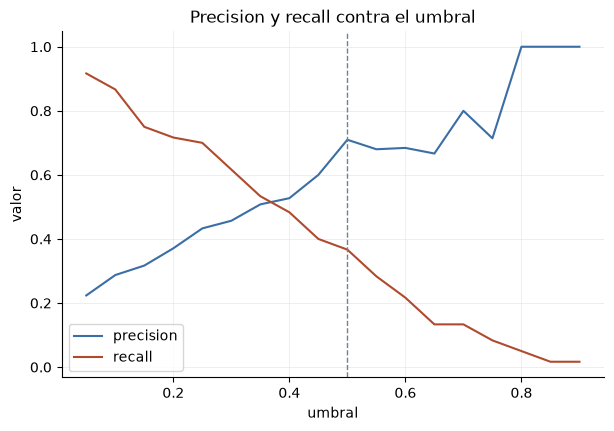

In [10]:
umbrales = np.arange(0.05, 0.91, 0.05)
precisiones = []
recalls = []

for umbral in umbrales:
    pred_u = (prob >= umbral)
    tp = ((pred_u == 1) & (y_test == 1)).sum()
    fp = ((pred_u == 1) & (y_test == 0)).sum()
    fn = ((pred_u == 0) & (y_test == 1)).sum()
    precisiones.append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(umbrales, precisiones, color=AZUL, label="precision")
ax.plot(umbrales, recalls, color=ROJO, label="recall")
ax.axvline(0.5, color=GRIS, ls="--", lw=1)
ax.set_xlabel("umbral")
ax.set_ylabel("valor")
ax.set_title("Precision y recall contra el umbral")
ax.legend()
eje_limpio(ax)
plt.show()

# Verificación (descomentar):
assert len(precisiones) == len(recalls) == len(umbrales) == 18

### Ejercicio 9 (0.20): AUC por pares

AUC sin fórmula, como en la sesión: tomar 5,000 canceladores al azar y 5,000 no canceladores al azar (con `rng_auc.choice`, en ese orden), y medir en qué fracción de los pares el cancelador recibió mayor probabilidad. Comparar contra `roc_auc_score`.

In [11]:
from sklearn.metrics import roc_auc_score

rng_auc = np.random.default_rng(7)

pos = prob[y_test.values == 1]   # probabilidades de los que cancelaron
neg = prob[y_test.values == 0]   # probabilidades de los que se quedaron
# luego, exactamente en este orden:
p_azar = rng_auc.choice(pos, 5000)
n_azar = rng_auc.choice(neg, 5000)
auc_pares = (p_azar > n_azar).mean()     # fracción de pares donde el cancelador tuvo mayor probabilidad
auc_sklearn = roc_auc_score(y_test, prob)

# Verificación (descomentar):
assert round(auc_pares, 3) == 0.821
assert round(auc_sklearn, 3) == 0.822

### Ejercicio 10 (0.20): ¿dice la verdad?

Agrupar las probabilidades del test en cajones con `pd.cut` (bordes [0, 0.2, 0.4, 0.6, 0.8, 1.0]) y construir la tabla de calibración: por cajón, el promedio de lo que el modelo dijo, la fracción que de verdad canceló y el número de clientes.

In [12]:
grupos = pd.cut(prob, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

calib = pd.DataFrame({"dijo": prob, "real": y_test.values}).groupby(grupos, observed=False).agg(
    dijo=("dijo", "mean"), real=("real", "mean"), clientes=("real", "size"))

# Verificación (descomentar):
assert calib["clientes"].tolist() == [244, 61, 36, 16, 3]

calib.round(2)

,dijo,real,clientes
"(0.0, 0.2]",0.07,0.07,244
"(0.2, 0.4]",0.29,0.23,61
"(0.4, 0.6]",0.48,0.44,36
"(0.6, 0.8]",0.69,0.62,16
"(0.8, 1.0]",0.85,1.00,3


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** Una llamada de retención cuesta Q25; un cliente que se va sin aviso cuesta Q1,500. Con la tabla del ejercicio 7, ¿qué umbral conviene y por qué? (Basta comparar el costo total de dos o tres umbrales.)

**(b)** El gerente quiere presentar el modelo diciendo acierta el 87% de las veces". Con los números de los ejercicios 4 y 6, explicar por qué ese argumento es débil y proponer el argumento honesto.

_(Responder editando esta celda)_

**Respuesta (a):** Conviene utilizar un umbral de 0.2, ya que con costos reales se nota que, en contra de un umbral de 0.5, hay una diferencia de casi la mitad: por ejemplo, de 116 alertas se ven varias alertas desperdiciadas con precisión 0.37.

**Respuesta (b):** El modelo "nadie cancela" ya acierta un 83%, por lo que una diferencia de 3% no es significativa. Además, de los 60 clientes que cancelaron, solo se avisó a 22 (recall 0.37), aunque de esas alertas el 71% eran canceladores reales (precision 0.71).

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

**Mini-bitácora de AI (Claude):**

- Ejercicio 2 (cliente a mano): Se preguntó cómo pasar de los valores originales del cliente (Q380, 4 meses, 2 reclamos) a la probabilidad sin usar `predict_proba`. Se entendió que primero hay que escalar cada valor con la misma media y desviación que usó el `StandardScaler` en el entrenamiento (`modelo[0].transform`), luego sumar el intercepto más cada valor escalado por su peso, y por último pasar ese número por la sigmoide; si se salta el escalado, la suma con los pesos no tiene sentido porque los pesos fueron ajustados sobre datos ya escalados.

- Ejercicio 3 (castigo / log loss): Se preguntó por qué el castigo `-log(p)` crece tanto cuando el modelo dice 0.01 a un cliente que sí canceló. Se entendió que el logaritmo castiga fuerte la confianza equivocada: decir 0.5 (no saber) cuesta poco, pero decir casi 0 a algo que sí pasó cuesta muchísimo más que el error proporcional sugeriría, y que por eso `log_loss` premia a un modelo que "duda" cuando no está seguro en vez de apostar fuerte y fallar.

- Ejercicio 4 (accuracy engañosa): Se preguntó por qué la accuracy del modelo perezoso ("nadie cancela") ya es 0.833 si nunca avisa a nadie. Se entendió que con solo 17% de cancelaciones, acertar diciendo "no" siempre ya acumula accuracy alta porque la mayoría de los clientes en efecto no cancela, y por eso la accuracy del modelo real (0.869) parece una mejora pequeña aunque el modelo sí distingue mejor quién cancela.

- Ejercicio 5 (tabla 2x2): Se preguntó cómo armar la tabla de TP, FP, FN, TN con máscaras booleanas en pandas/numpy en vez de un bucle. Se entendió que `(pred == 1) & (y_test == 1)` compara elemento por elemento y `.sum()` cuenta los `True`, y que ordenar la tabla como filas "Cancelado/Se queda" y columnas "dijo cancela/dijo que se queda" es lo que hace visible de un vistazo cuál error (FP o FN) pesa más para el negocio.

- Ejercicio 8 (gráficas): Se preguntó cómo graficar precision y recall contra el umbral con matplotlib, usando `ax.plot` para cada serie, `ax.axvline` para marcar una línea vertical punteada en 0.5, y `eje_limpio` para el estilo de los ejes. Se entendió que subir el umbral hace que el modelo sea más exigente para alertar: la precisión sube (las pocas alertas que da son más confiables) pero el recall baja (deja pasar más canceladores reales sin avisar), y que la línea vertical en 0.5 marca el umbral por defecto usado en los ejercicios anteriores.

- Ejercicio 9 (AUC por pares): Se preguntó qué mide el AUC cuando se calcula "por pares" en vez de con la fórmula de sklearn. Se entendió que consiste en tomar muchos pares al azar (un cliente que sí canceló y uno que no) y contar en qué fracción de esos pares el modelo le dio mayor probabilidad al que sí canceló; esa fracción es, en el límite, lo mismo que calcula `roc_auc_score`, y por eso ambos números (0.821 y 0.822) casi coinciden. También se aclaró el orden correcto de `rng_auc.choice(pos, 5000)` y `rng_auc.choice(neg, 5000)` para que el resultado fuera reproducible con la semilla fija.